In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data/StudentPerformanceFactors.csv')
df


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [3]:
df.shape

(6607, 20)

In [4]:
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df = df.dropna()

A small number of missing values were identified in categorical columns such as Teacher_Quality, Parental_Education_Level, and Distance_from_Home. Since the number of missing entries was minimal compared to the dataset size, these rows were removed to ensure consistency in further analysis and modeling.

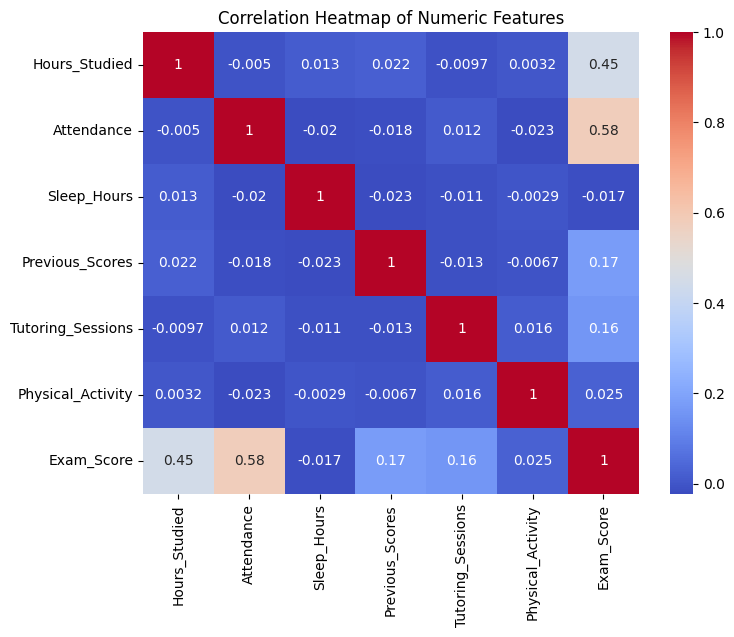

In [8]:
numeric_corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The correlation heatmap shows the relationships between numerical variables in the dataset. Among all features, attendance has the strongest positive correlation with exam score (0.58), followed by hours studied (0.45). This suggests that students who attend more classes and spend more time studying tend to perform better on exams. Other variables such as previous scores and tutoring sessions show weaker positive relationships, while sleep hours and physical activity appear to have little to no correlation with exam performance.

In [9]:
numeric_corr['Exam_Score'].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.580259
Hours_Studied        0.445104
Previous_Scores      0.174283
Tutoring_Sessions    0.156829
Physical_Activity    0.025148
Sleep_Hours         -0.017171
Name: Exam_Score, dtype: float64

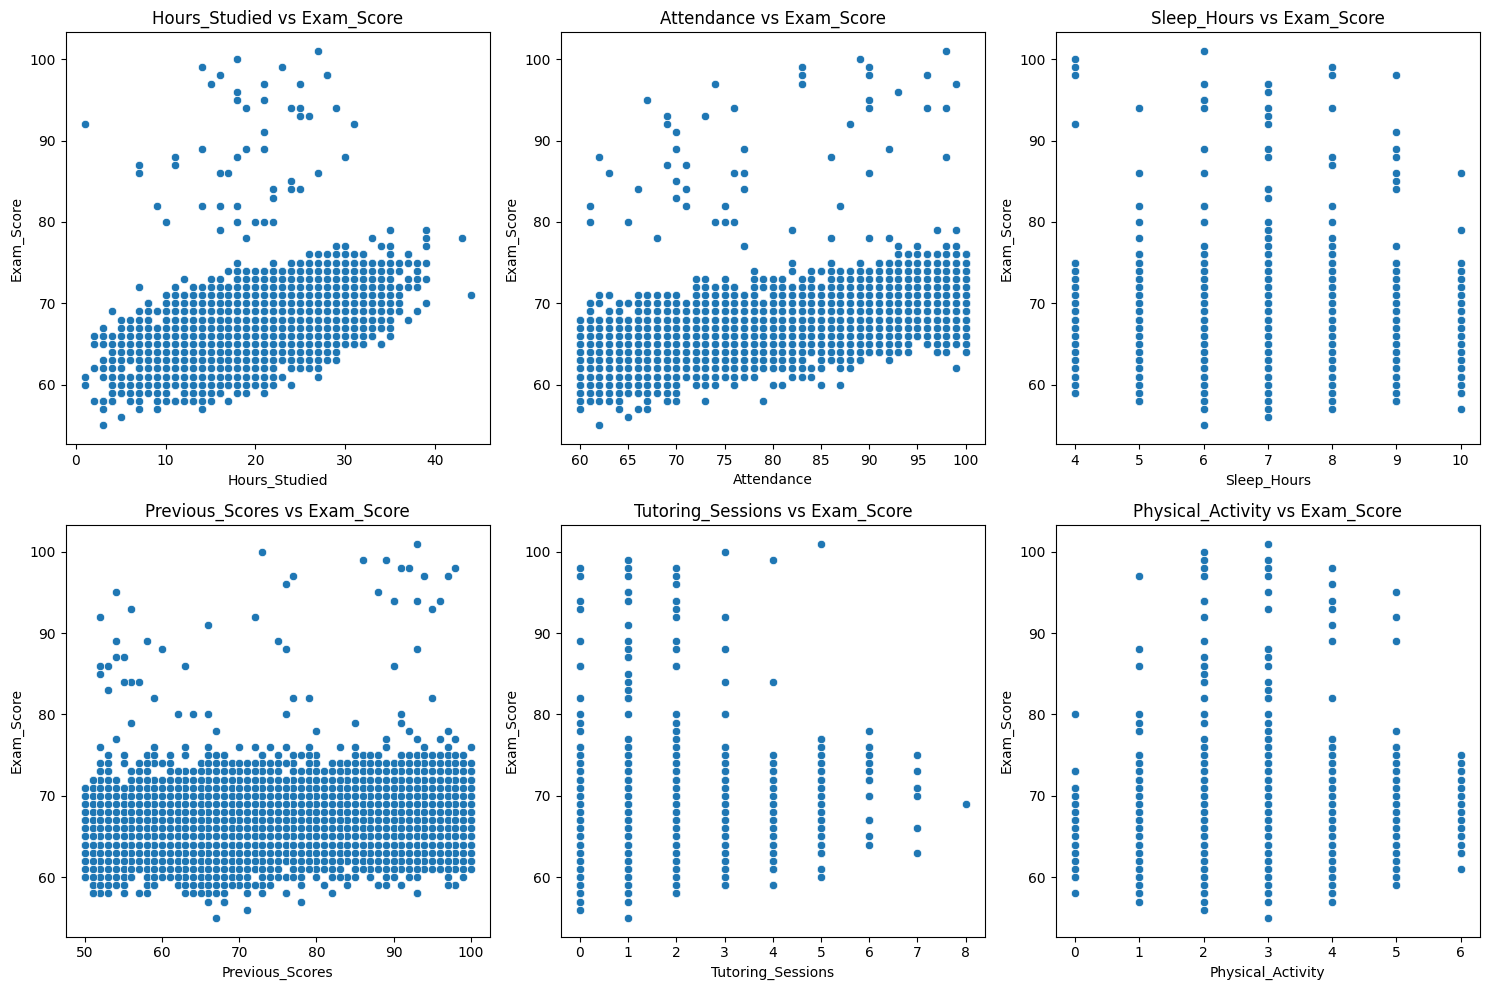

In [10]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('Exam_Score')

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'{col} vs Exam_Score')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The scatterplots show how each numeric variable relates to exam score. Attendance and hours studied display the strongest positive relationships, as higher values in these variables generally correspond to higher exam scores. Previous scores and tutoring sessions show weaker positive trends, suggesting they may have some influence but are not as strong. In contrast, sleep hours and physical activity do not show a clear pattern, indicating little to no direct relationship with exam performance. Overall, the results suggest that consistent attendance and study time are the most important numeric factors associated with higher exam scores.

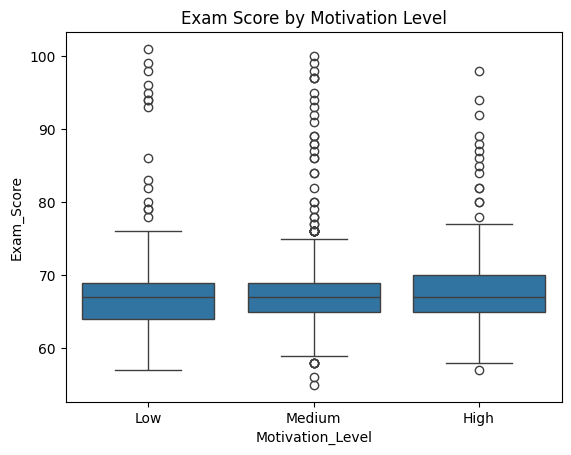

In [11]:
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score')
plt.title('Exam Score by Motivation Level')
plt.show()

Students with higher motivation levels tend to have slightly higher median exam scores. The distribution for “High” motivation is slightly shifted upward compared to “Low,” suggesting that motivation has a positive but moderate impact on performance.

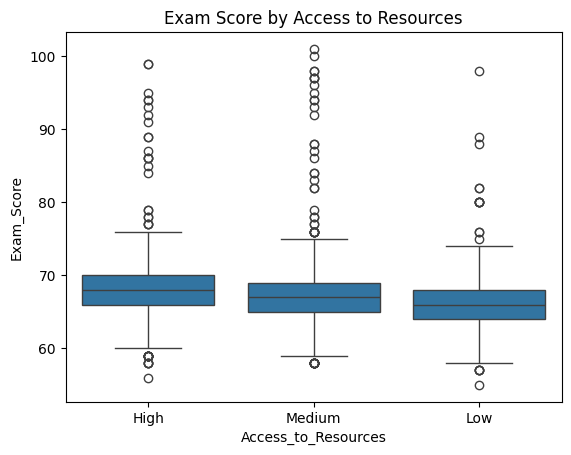

In [12]:
sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score')
plt.title('Exam Score by Access to Resources')
plt.show()

Students with higher access to resources generally show slightly higher exam scores. However, the differences between groups are not very large, indicating that while resources help, they may not be the most dominant factor.

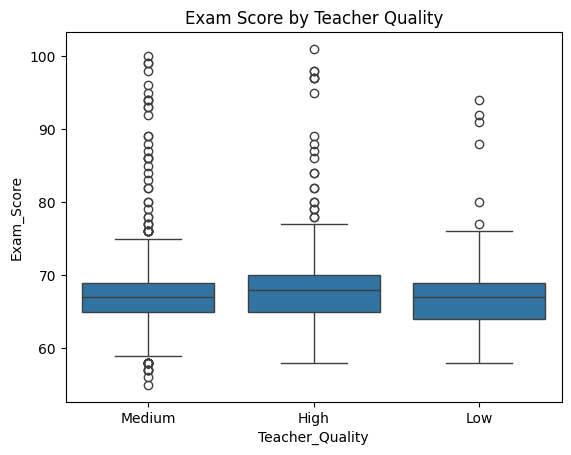

In [13]:
sns.boxplot(data=df, x='Teacher_Quality', y='Exam_Score')
plt.title('Exam Score by Teacher Quality')
plt.show()

Students with higher teacher quality tend to perform slightly better on average. The median exam score for “High” teacher quality is higher than “Low,” suggesting that teaching quality has a positive influence, though the effect is moderate.

The scatterplots and boxplots show the presence of some outliers, particularly at higher exam scores. These points represent students who performed significantly better than the majority. Since these values are realistic and not data errors, they were retained in the analysis. However, they may slightly influence the overall trends observed.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 4.173262062207912
R^2: 0.7314386522127074


In [15]:
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients.sort_values(ascending=False).head(10)

Peer_Influence_Positive                  1.014880
Internet_Access_Yes                      0.900608
Distance_from_Home_Near                  0.841829
Extracurricular_Activities_Yes           0.566723
Peer_Influence_Neutral                   0.561867
Parental_Education_Level_Postgraduate    0.521576
Tutoring_Sessions                        0.482777
Distance_from_Home_Moderate              0.304964
Hours_Studied                            0.295834
Physical_Activity                        0.200224
dtype: float64